### Delivery Logistics Dataset (India – Multi-Partner)


### About Dataset
This dataset provides an extensive and realistic representation of last-mile delivery logistics across multiple regions and delivery partners in India. It contains 25,000 delivery records, each reflecting operational conditions, package characteristics, environmental factors, and delivery outcomes.

The data includes major logistics providers such as Delhivery, Blue Dart, Ekart, DHL, FedEx, Shadowfax, XpressBees, Amazon Logistics, and Ecom Express. Each record describes key delivery attributes including package type, vehicle used, delivery mode, weather condition, travel distance, package weight, and cost estimation.

Performance-related fields such as actual delivery time, expected time, delay status, and final delivery status provide insights into how real-world constraints like traffic, vehicle type, and weather influence delivery efficiency. Additionally, a delivery rating is included to reflect customer feedback, helping explore service quality patterns.

The dataset is ideal for studying logistics operations, delay analysis, delivery cost behavior, route efficiency, environmental impact, and overall supply chain performance. Since the dataset is synthetically generated, it contains no personal information and is safe for academic, analytical, or business-oriented research.

The dataset was created using a multi-stage synthetic modeling pipeline:

Delivery Setup Each record is assigned: A delivery partner A vehicle type A package type (electronics, groceries, furniture, fragile items, etc.) A delivery mode (Standard, Express, Same Day, Two Day)

Distance & Weight Generation Distance ranges from 1–300 km and package weight from 0.2–50 kg, representing urban, semi-urban, and intercity operations.

Environmental Impact Weather conditions such as Rainy, Foggy, Stormy, Hot, and Cold influence travel time using probabilistic delays.

Delivery Time Calculation Delivery time is computed using: Base travel time (depending on distance and vehicle speed) Weather delays Traffic delays

Expected Time & Delay Identification Expected delivery time varies by mode (Express, Same Day, etc.). Delay is marked as “Yes” if actual time exceeds expected time.

Delivery Status & Rating If not delayed → Delivered. If delayed → “Delayed” or “Failed” with realistic probability. Ratings follow service outcome: higher for successful deliveries, lower for failures.

Cost Generation Cost is based on: Distance Weight Delivery mode (Express and Same Day include surcharges)

Validation Data validated for: Logical consistency Range verification Clean formatting No missing values

In [1]:
#importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading Dataset
df=pd.read_csv("Delivery_Logistics.csv")

In [3]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [5]:
#checking null value
df.isnull().sum()
#observation : no null values

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

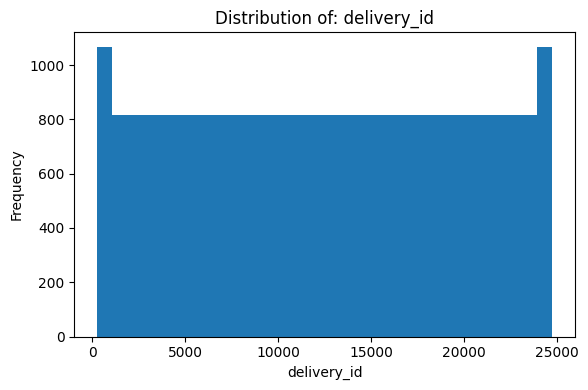

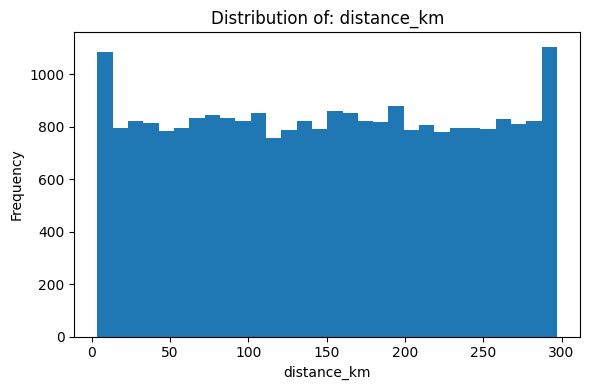

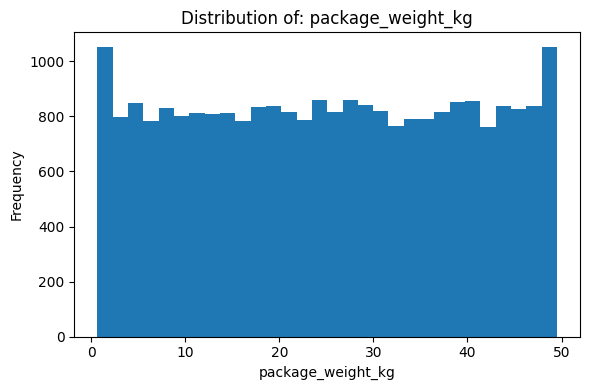

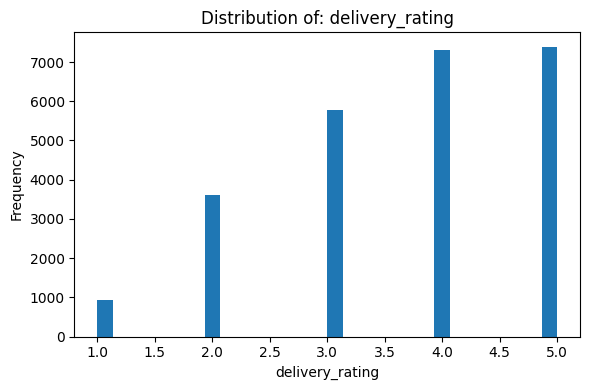

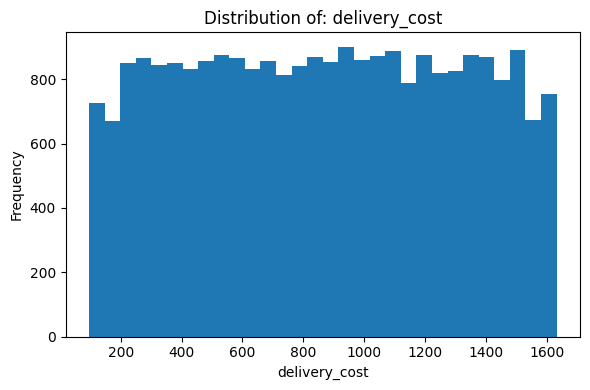

In [6]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

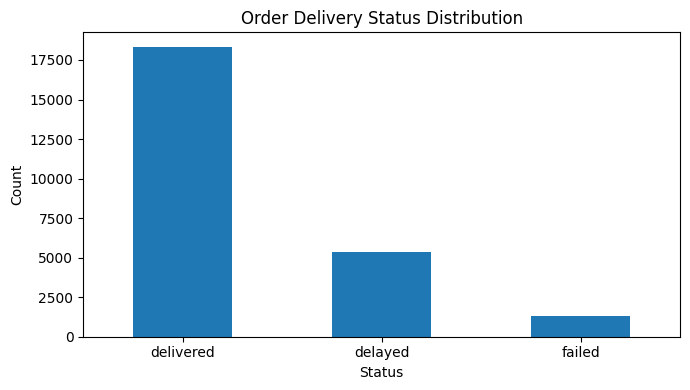

In [7]:

df["delivery_status"].value_counts().plot(kind='bar', figsize=(7,4))
plt.title("Order Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

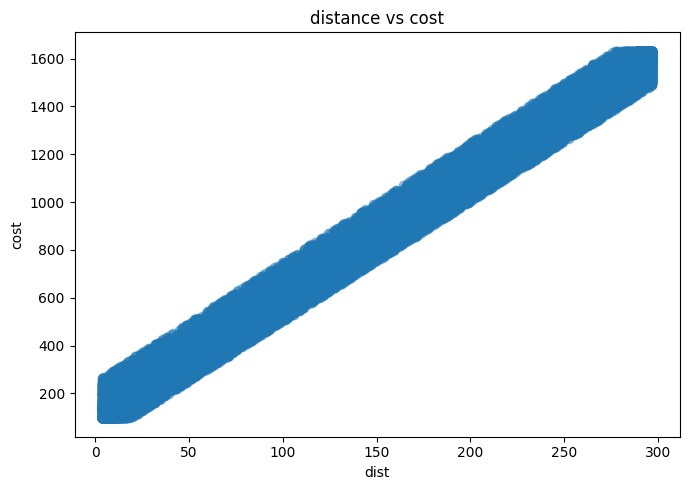

In [8]:

plt.figure(figsize=(7,5))
plt.scatter(df["distance_km"], df["delivery_cost"], alpha=0.4)
plt.title(f"{"distance"} vs {"cost"}")
plt.xlabel("dist")
plt.ylabel("cost")
plt.tight_layout()
plt.show()

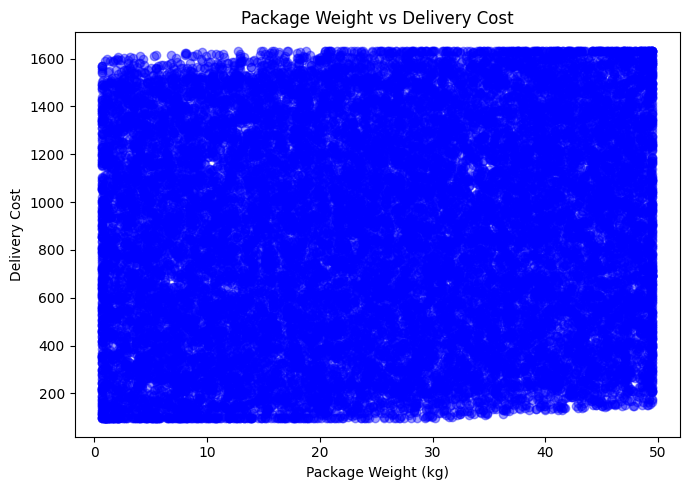

In [9]:

# Scatter plot: weight vs cost
plt.figure(figsize=(7,5))
plt.scatter(df["package_weight_kg"], df["delivery_cost"], alpha=0.4, c="blue")
plt.title("Package Weight vs Delivery Cost")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Cost")
plt.tight_layout()
plt.show()

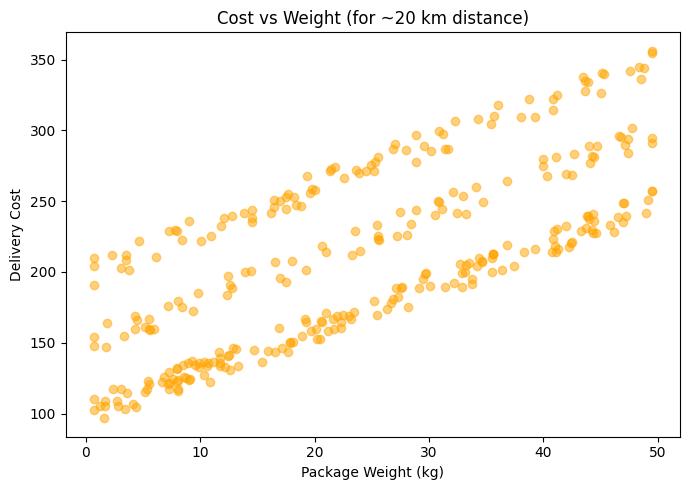

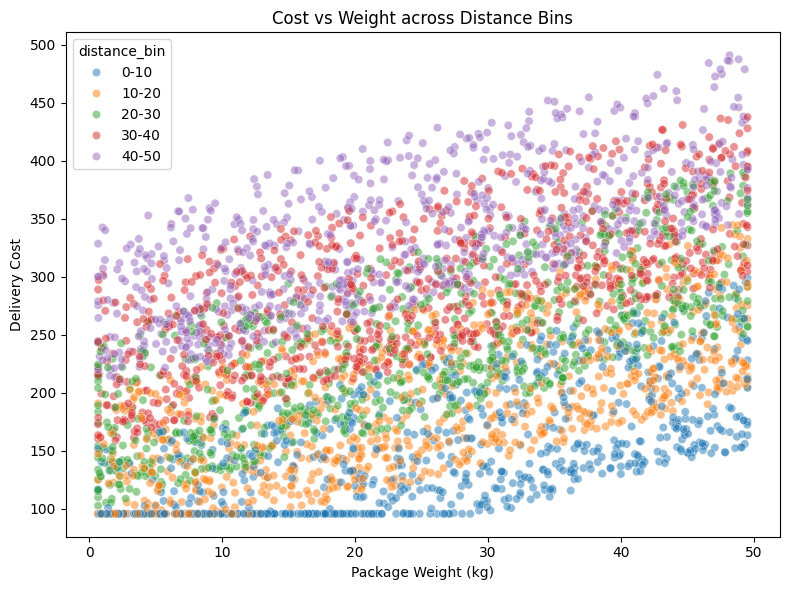

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example: filter for ~20 km distance range
subset = df[(df["distance_km"] >= 18) & (df["distance_km"] <= 22)]

plt.figure(figsize=(7,5))
plt.scatter(subset["package_weight_kg"], subset["delivery_cost"], alpha=0.5, c="orange")
plt.title("Cost vs Weight (for ~20 km distance)")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Cost")
plt.tight_layout()
plt.show()

# Relation across multiple distance bins
bins = [0,10,20,30,40,50]
df['distance_bin'] = pd.cut(df['distance_km'], bins=bins, labels=['0-10','10-20','20-30','30-40','40-50'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="package_weight_kg", y="delivery_cost", hue="distance_bin", alpha=0.5)
plt.title("Cost vs Weight across Distance Bins")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Cost")
plt.tight_layout()
plt.show()
df.drop(['distance_bin'],axis=1,inplace=True)

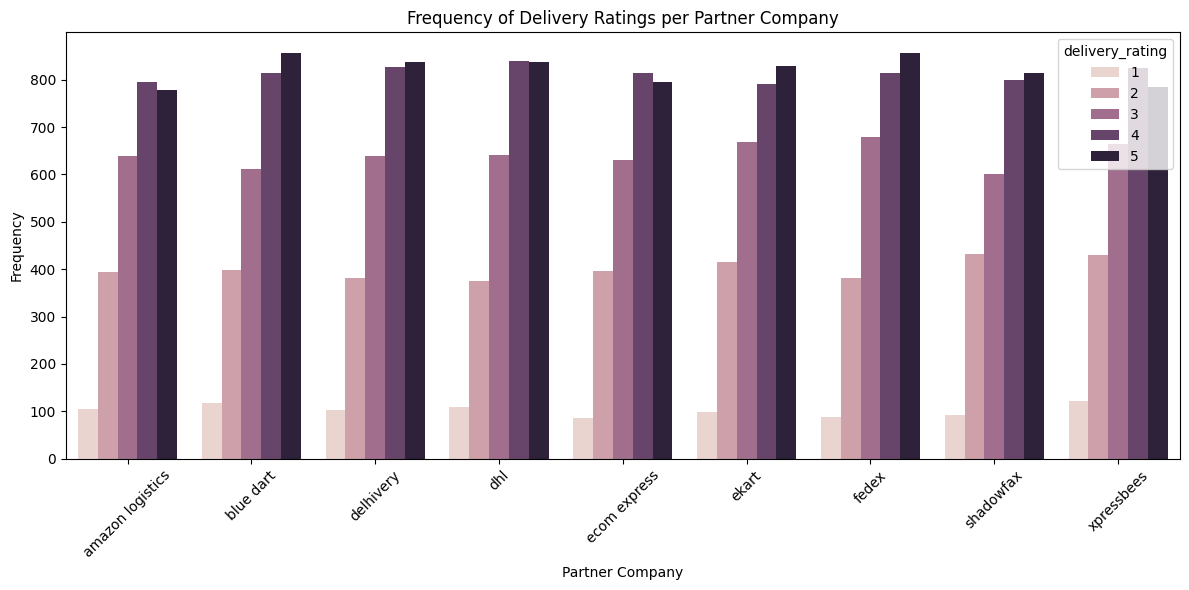

In [11]:
rating_counts = df.groupby(['delivery_partner', 'delivery_rating']).size().reset_index(name='count')

# Plot bar graph
plt.figure(figsize=(12,6))
sns.barplot(data=rating_counts, x='delivery_partner', y='count', hue='delivery_rating')
plt.title('Frequency of Delivery Ratings per Partner Company')
plt.xlabel('Partner Company')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

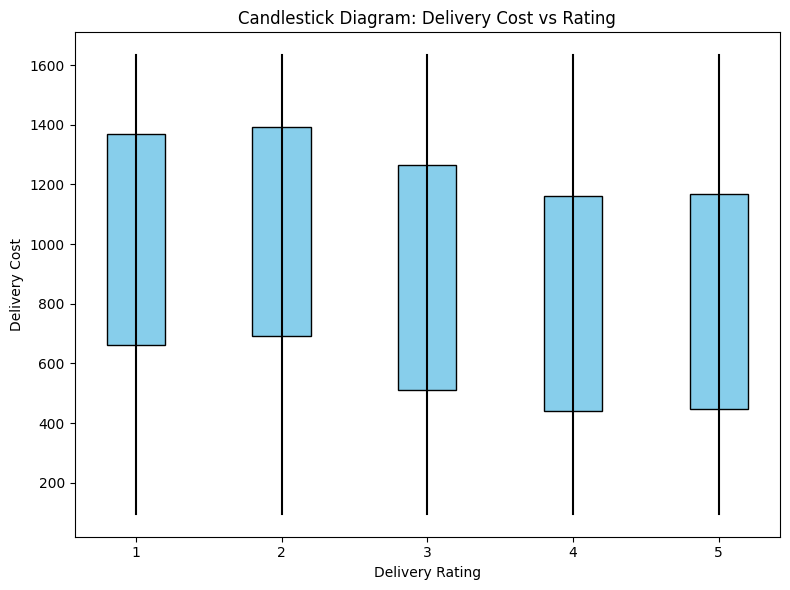

In [12]:

# Group by rating and calculate stats
summary = df.groupby('delivery_rating')['delivery_cost'].describe()

ratings = summary.index
mins = summary['min']
maxs = summary['max']
q1 = summary['25%']
q3 = summary['75%']

plt.figure(figsize=(8,6))

# Draw candlesticks for each rating
for i, rating in enumerate(ratings):
    # Vertical line (low to high)
    plt.plot([i, i], [mins[rating], maxs[rating]], color='black')
    
    # Rectangle (Q1 to Q3)
    plt.bar(i, q3[rating]-q1[rating], bottom=q1[rating], width=0.4, color='skyblue', edgecolor='black')

# Formatting
plt.xticks(np.arange(len(ratings)), ratings)
plt.title("Candlestick Diagram: Delivery Cost vs Rating")
plt.xlabel("Delivery Rating")
plt.ylabel("Delivery Cost")
plt.tight_layout()
plt.show